# Day 11 – Clustering
### 20-Day ML Revision Planner | Phase: Advanced ML

**Topics covered:**
1. K-Means: Centroids & Inertia
2. Choosing K: Elbow Method & Silhouette Score
3. Hierarchical Clustering
4. DBSCAN
5. Gaussian Mixture Models (GMM)
6. K-Means vs DBSCAN: When to Use Each
7. Mini Project: Customer Segmentation
8. Interview Questions
9. Active Recall Checklist

**Revision rule:** Learn → Close Notes → Recall → Code → Debug → Explain → Interview Question.

---


In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import make_blobs, make_moons

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)
np.random.seed(42)
print("Setup complete.")


Setup complete.


## 1. K-Means: Centroids & Inertia

### What?
**K-Means** is an **unsupervised** algorithm (recall Day 4) that partitions data into $K$ clusters, each represented by a **centroid** — the mean position of all points assigned to that cluster.

**Algorithm:**
1. Choose $K$ and initialize $K$ centroids (often randomly, or via `k-means++` for smarter initialization).
2. **Assign** each point to its nearest centroid (by Euclidean distance — recall Day 1's L2 norm).
3. **Update** each centroid to the mean of the points now assigned to it.
4. Repeat steps 2-3 until centroids stop moving (convergence).

**Inertia** (the objective K-Means minimizes): the sum of squared distances from each point to its assigned centroid:
$$\text{Inertia} = \sum_{i=1}^{m} \min_{\mu_k} \|x_i - \mu_k\|^2$$

### Why?
K-Means is simple, fast, and scales well — a great default first choice for finding roughly spherical, similarly-sized clusters (e.g., customer segments, document topics).

### How? — Key Considerations
- **Must choose $K$ in advance** (unlike DBSCAN, below).
- **Sensitive to initialization** — can converge to a poor local minimum; `k-means++` (sklearn's default) mitigates this by spreading initial centroids apart.
- **Assumes roughly spherical, similarly-sized clusters** — struggles with elongated, nested, or very differently-sized clusters.
- **Requires feature scaling** (recall Day 4) since it's entirely distance-based, just like KNN (Day 6).


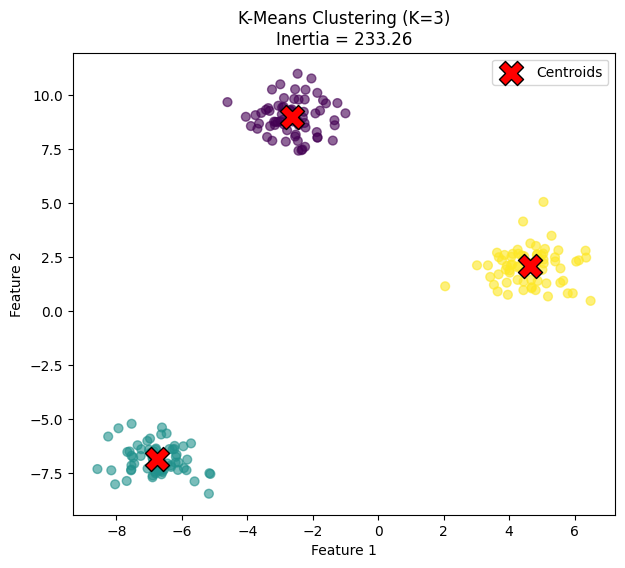

Number of iterations until convergence: 2
Final inertia (sum of squared distances to nearest centroid): 233.2629


In [2]:
# Visualize K-Means step by step on a simple 2D toy dataset
X_toy, y_true_toy = make_blobs(n_samples=200, centers=3, cluster_std=0.8, random_state=42)

kmeans_demo = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
labels = kmeans_demo.fit_predict(X_toy)
centroids = kmeans_demo.cluster_centers_

plt.figure(figsize=(7, 6))
plt.scatter(X_toy[:, 0], X_toy[:, 1], c=labels, cmap='viridis', alpha=0.6, s=40)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=300, edgecolor='black', label='Centroids')
plt.title(f"K-Means Clustering (K=3)\nInertia = {kmeans_demo.inertia_:.2f}")
plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
plt.legend()
plt.show()

print(f"Number of iterations until convergence: {kmeans_demo.n_iter_}")
print(f"Final inertia (sum of squared distances to nearest centroid): {kmeans_demo.inertia_:.4f}")


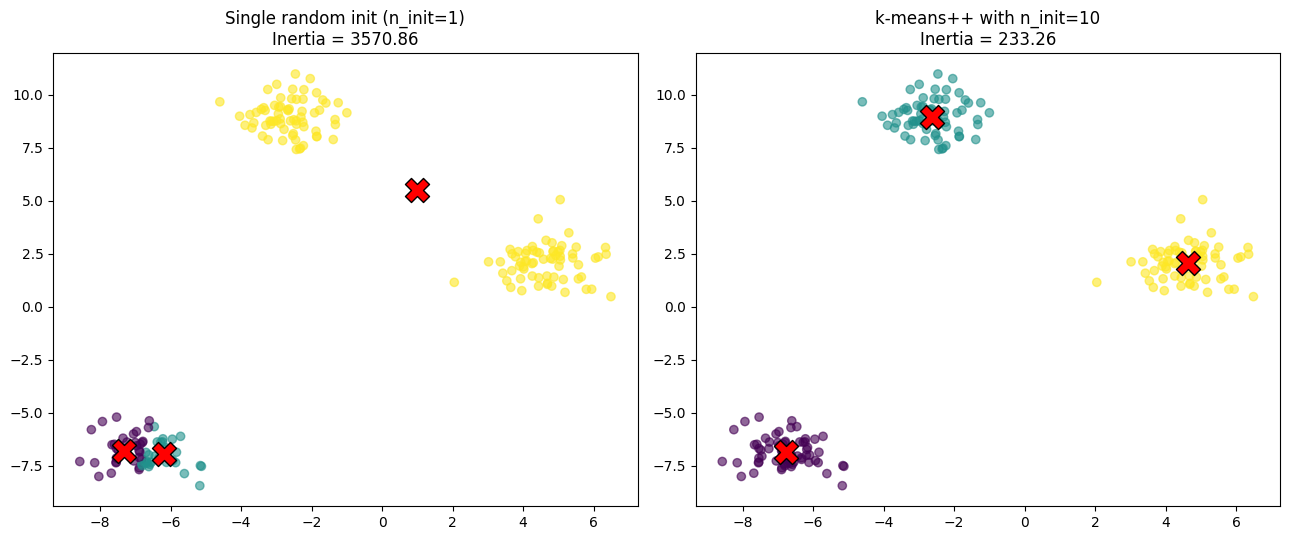

--> Lower inertia = tighter, better-formed clusters. k-means++ with multiple restarts
    reliably avoids poor local minima that a single random initialization can fall into.


In [3]:
# Show WHY initialization matters: bad random init vs k-means++ (multiple restarts)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Force a poor single random initialization (n_init=1, random init instead of k-means++)
kmeans_bad_init = KMeans(n_clusters=3, init='random', n_init=1, random_state=7)
labels_bad = kmeans_bad_init.fit_predict(X_toy)
axes[0].scatter(X_toy[:, 0], X_toy[:, 1], c=labels_bad, cmap='viridis', alpha=0.6)
axes[0].scatter(kmeans_bad_init.cluster_centers_[:, 0], kmeans_bad_init.cluster_centers_[:, 1],
                c='red', marker='X', s=300, edgecolor='black')
axes[0].set_title(f"Single random init (n_init=1)\nInertia = {kmeans_bad_init.inertia_:.2f}")

# k-means++ with multiple restarts (sklearn default behavior)
kmeans_good_init = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=7)
labels_good = kmeans_good_init.fit_predict(X_toy)
axes[1].scatter(X_toy[:, 0], X_toy[:, 1], c=labels_good, cmap='viridis', alpha=0.6)
axes[1].scatter(kmeans_good_init.cluster_centers_[:, 0], kmeans_good_init.cluster_centers_[:, 1],
                c='red', marker='X', s=300, edgecolor='black')
axes[1].set_title(f"k-means++ with n_init=10\nInertia = {kmeans_good_init.inertia_:.2f}")

plt.tight_layout()
plt.show()
print("--> Lower inertia = tighter, better-formed clusters. k-means++ with multiple restarts")
print("    reliably avoids poor local minima that a single random initialization can fall into.")


## 2. Choosing K: The Elbow Method & Silhouette Score

### What?
Since K-Means requires choosing $K$ upfront, we need principled ways to select it:
- **Elbow Method**: plot inertia vs. $K$. Inertia always decreases as $K$ increases (more clusters = tighter fit), but the *rate* of decrease slows down after the "true" number of clusters — look for the "elbow" (bend) in the curve.
- **Silhouette Score**: for each point, measures how similar it is to its own cluster vs. the nearest other cluster:
  $$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$
  where $a(i)$ = average distance to points in the same cluster, $b(i)$ = average distance to points in the nearest *other* cluster. Ranges from -1 (poor) to +1 (excellent); averaged across all points gives an overall score for a given $K$.

### Why?
Choosing $K$ poorly leads to either **underfitting the structure** (too few clusters, merging distinct groups) or **overfitting/fragmenting** (too many clusters, splitting a natural group unnecessarily). These two methods give complementary, quantitative guidance.

### How?
- Elbow method: **visual/subjective** — look for where the curve "bends."
- Silhouette score: **quantitative** — pick the $K$ that **maximizes** the average silhouette score. More reliable than the elbow method when the elbow isn't visually obvious.


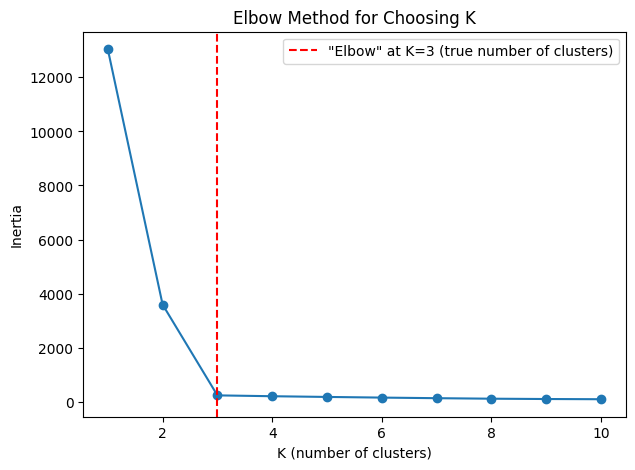

In [4]:
# Elbow method: plot inertia across a range of K values
K_range = range(1, 11)
inertias = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_toy)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(list(K_range), inertias, marker='o')
plt.axvline(3, color='red', linestyle='--', label='"Elbow" at K=3 (true number of clusters)')
plt.xlabel("K (number of clusters)"); plt.ylabel("Inertia")
plt.title("Elbow Method for Choosing K")
plt.legend()
plt.show()


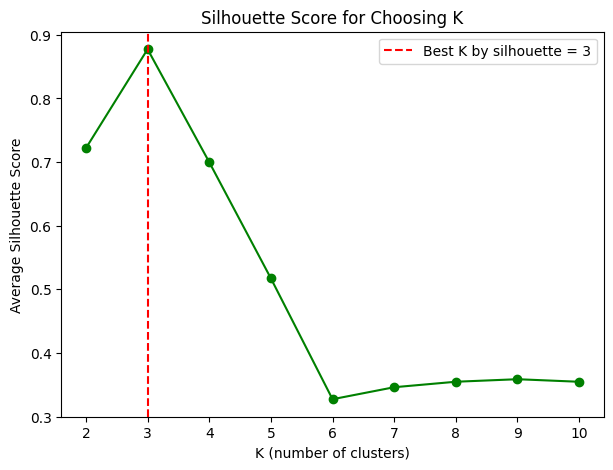

Best K by silhouette score: 3 (score = 0.8773)


In [5]:
# Silhouette score analysis across the same range of K
silhouette_scores = []
for k in range(2, 11):  # silhouette score requires at least 2 clusters
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_toy)
    score = silhouette_score(X_toy, km.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(7, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o', color='green')
best_k_sil = list(range(2, 11))[np.argmax(silhouette_scores)]
plt.axvline(best_k_sil, color='red', linestyle='--', label=f'Best K by silhouette = {best_k_sil}')
plt.xlabel("K (number of clusters)"); plt.ylabel("Average Silhouette Score")
plt.title("Silhouette Score for Choosing K")
plt.legend()
plt.show()

print(f"Best K by silhouette score: {best_k_sil} (score = {max(silhouette_scores):.4f})")


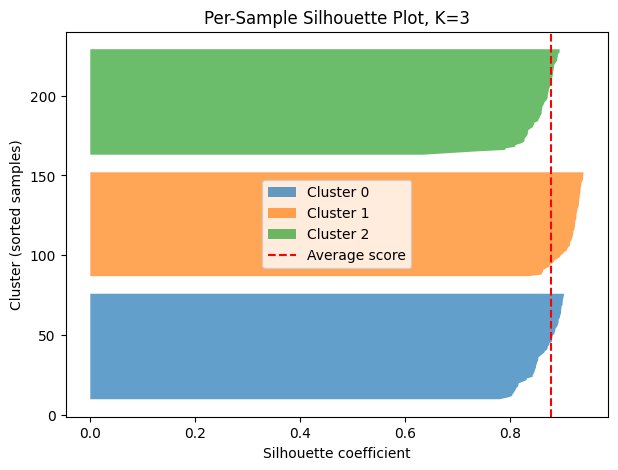

--> Wide, uniformly high bars (close to 1) indicate well-separated, cohesive clusters.
    Bars dipping below 0 indicate points that may be assigned to the wrong cluster.


In [6]:
# Detailed silhouette plot for K=3 (per-sample silhouette values, not just the average)
km_3 = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X_toy)
sample_silhouette_values = silhouette_samples(X_toy, km_3.labels_)

fig, ax = plt.subplots(figsize=(7, 5))
y_lower = 10
for i in range(3):
    cluster_values = sample_silhouette_values[km_3.labels_ == i]
    cluster_values.sort()
    size_cluster_i = len(cluster_values)
    y_upper = y_lower + size_cluster_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_values, alpha=0.7, label=f'Cluster {i}')
    y_lower = y_upper + 10

ax.axvline(silhouette_score(X_toy, km_3.labels_), color='red', linestyle='--', label='Average score')
ax.set_xlabel("Silhouette coefficient"); ax.set_ylabel("Cluster (sorted samples)")
ax.set_title("Per-Sample Silhouette Plot, K=3")
ax.legend()
plt.show()
print("--> Wide, uniformly high bars (close to 1) indicate well-separated, cohesive clusters.")
print("    Bars dipping below 0 indicate points that may be assigned to the wrong cluster.")


## 3. Hierarchical Clustering

### What?
Builds a **tree of nested clusters** (a **dendrogram**) rather than a single flat partition.
- **Agglomerative (bottom-up)**: start with every point as its own cluster, repeatedly **merge** the two closest clusters, until only one remains.
- **Divisive (top-down)**: start with all points in one cluster, repeatedly **split** — much less common in practice.

**Linkage criteria** (how "distance between clusters" is defined):
- **Single linkage**: minimum distance between any two points across clusters.
- **Complete linkage**: maximum distance between any two points across clusters.
- **Average linkage**: average distance between all cross-cluster point pairs.
- **Ward linkage**: minimizes the increase in total within-cluster variance (often gives the most balanced, K-Means-like clusters).

### Why?
Unlike K-Means, hierarchical clustering **doesn't require specifying $K$ upfront** — you can inspect the full dendrogram and "cut" it at any level to get a different number of clusters, and it naturally reveals nested/hierarchical group structure (e.g., species → genus → family).

### How?
The dendrogram's height at which two clusters merge represents their dissimilarity — cutting the tree horizontally at a chosen height yields a specific number of flat clusters.


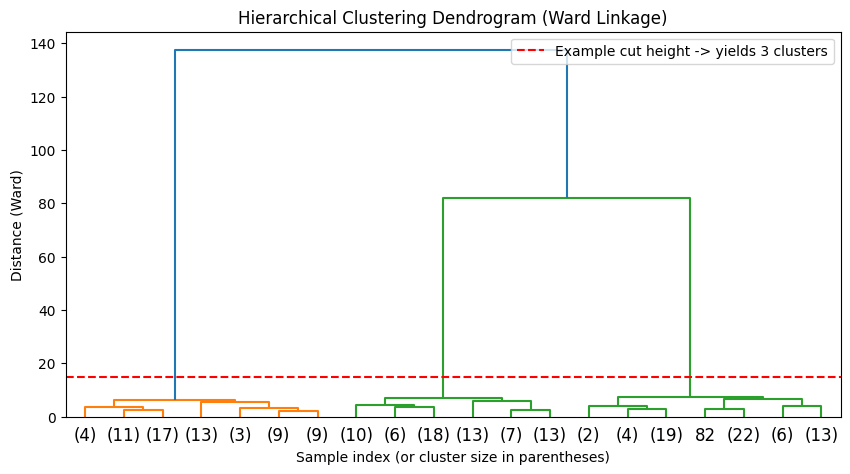

In [7]:
# Build and visualize a dendrogram using Ward linkage
Z = linkage(X_toy, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='lastp', p=20)  # show only the last 20 merges for readability
plt.axhline(y=15, color='red', linestyle='--', label='Example cut height -> yields 3 clusters')
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Sample index (or cluster size in parentheses)")
plt.ylabel("Distance (Ward)")
plt.legend()
plt.show()


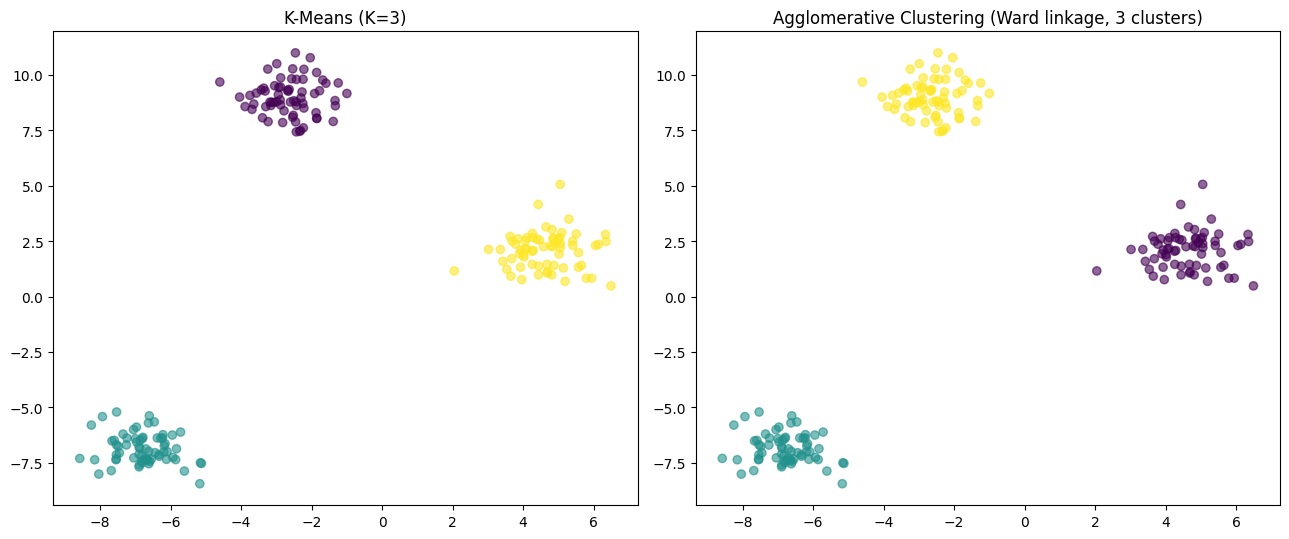

--> On well-separated, roughly spherical blobs, both methods typically agree closely.


In [8]:
# Compare Agglomerative Clustering (cut to 3 clusters) against K-Means on the same data
agg_clustering = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg_clustering.fit_predict(X_toy)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].scatter(X_toy[:, 0], X_toy[:, 1], c=km_3.labels_, cmap='viridis', alpha=0.6)
axes[0].set_title("K-Means (K=3)")
axes[1].scatter(X_toy[:, 0], X_toy[:, 1], c=agg_labels, cmap='viridis', alpha=0.6)
axes[1].set_title("Agglomerative Clustering (Ward linkage, 3 clusters)")
plt.tight_layout()
plt.show()
print("--> On well-separated, roughly spherical blobs, both methods typically agree closely.")


## 4. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

### What?
DBSCAN groups together points that are **densely packed**, marking points in low-density regions as **noise/outliers**. It's defined by two parameters:
- **`eps`**: the maximum distance between two points to be considered neighbors.
- **`min_samples`**: minimum number of points required within `eps` to form a "dense region" (core point).

**Point types:**
- **Core point**: has at least `min_samples` neighbors within `eps`.
- **Border point**: within `eps` of a core point, but doesn't itself have enough neighbors.
- **Noise point**: neither — doesn't belong to any cluster.

### Why?
Unlike K-Means, DBSCAN:
- **Doesn't require specifying the number of clusters upfront** — it discovers this from the data's density structure.
- Can find **arbitrarily shaped clusters** (not just spherical) — e.g., crescents, spirals.
- **Naturally identifies outliers/noise** as a byproduct, rather than forcing every point into some cluster.

### How? — Trade-offs
- Struggles when clusters have **very different densities** (a single `eps` may not suit all of them).
- Sensitive to the choice of `eps` and `min_samples` — often tuned using a "k-distance plot" (distance to the $k$-th nearest neighbor, looking for a similar "elbow").


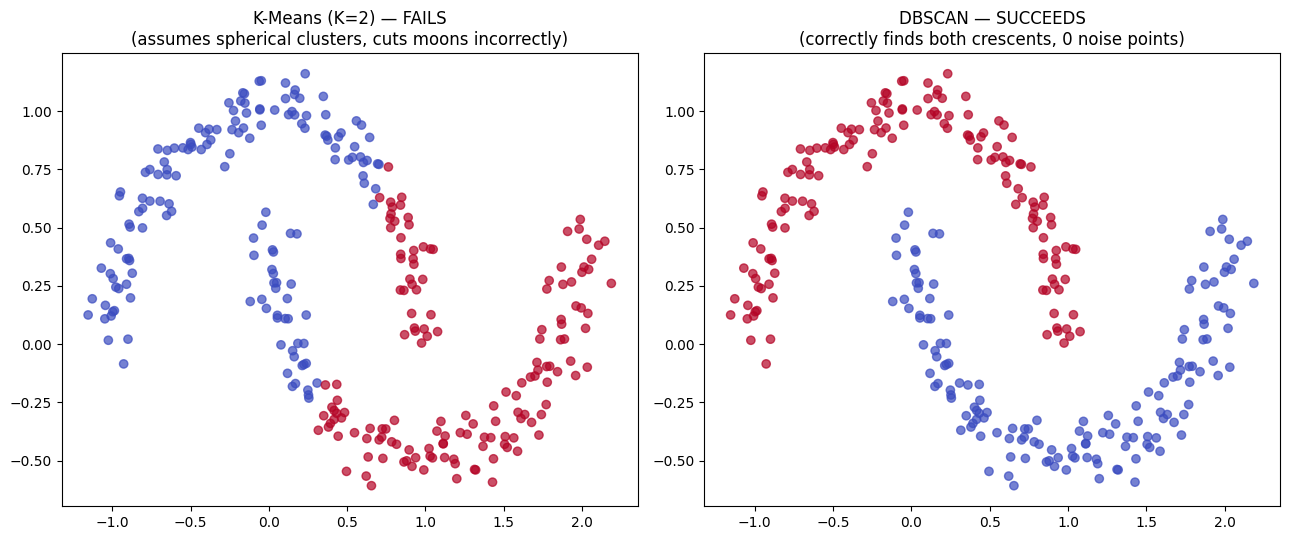

In [9]:
# The canonical case where DBSCAN shines and K-Means fails: non-convex, moon-shaped clusters
X_moons, y_moons = make_moons(n_samples=300, noise=0.07, random_state=42)

kmeans_moons = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X_moons)
dbscan_moons = DBSCAN(eps=0.2, min_samples=5).fit(X_moons)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=kmeans_moons.labels_, cmap='coolwarm', alpha=0.7)
axes[0].set_title("K-Means (K=2) — FAILS\n(assumes spherical clusters, cuts moons incorrectly)")

axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=dbscan_moons.labels_, cmap='coolwarm', alpha=0.7)
n_noise = np.sum(dbscan_moons.labels_ == -1)
axes[1].set_title(f"DBSCAN — SUCCEEDS\n(correctly finds both crescents, {n_noise} noise points)")

plt.tight_layout()
plt.show()


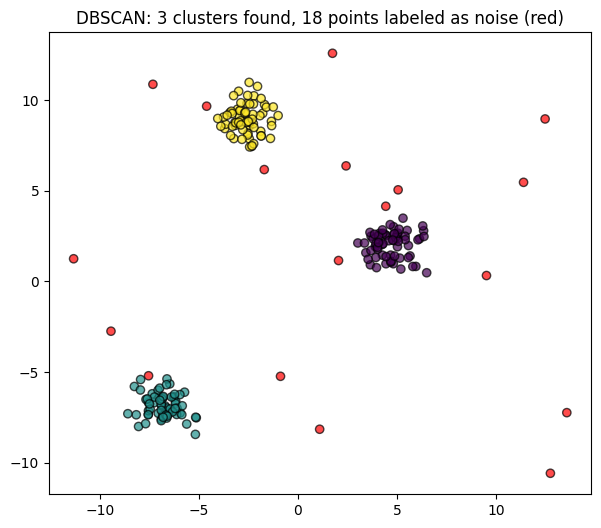

--> DBSCAN automatically isolates the scattered, low-density outlier points without any
    need to specify K, and without forcing them into an existing cluster.


In [10]:
# DBSCAN with injected outliers -- demonstrate automatic noise detection
np.random.seed(9)
X_with_outliers = np.vstack([X_toy, np.random.uniform(X_toy.min()-3, X_toy.max()+3, (15, 2))])

dbscan_outliers = DBSCAN(eps=0.8, min_samples=5).fit(X_with_outliers)
n_clusters_found = len(set(dbscan_outliers.labels_)) - (1 if -1 in dbscan_outliers.labels_ else 0)
n_noise_found = np.sum(dbscan_outliers.labels_ == -1)

plt.figure(figsize=(7, 6))
colors = ['red' if lbl == -1 else plt.cm.viridis(lbl / max(dbscan_outliers.labels_.max(), 1))
          for lbl in dbscan_outliers.labels_]
plt.scatter(X_with_outliers[:, 0], X_with_outliers[:, 1], c=colors, alpha=0.7, edgecolor='k')
plt.title(f"DBSCAN: {n_clusters_found} clusters found, {n_noise_found} points labeled as noise (red)")
plt.show()
print("--> DBSCAN automatically isolates the scattered, low-density outlier points without any")
print("    need to specify K, and without forcing them into an existing cluster.")


## 5. Gaussian Mixture Models (GMM)

### What?
A **probabilistic** clustering method that models the data as a mixture of $K$ **Gaussian distributions**, each with its own mean, covariance, and mixing weight. Unlike K-Means's **hard** assignments, GMM gives **soft** assignments — a probability of belonging to each cluster.

Fitting is done via the **Expectation-Maximization (EM)** algorithm:
1. **E-step**: given current Gaussian parameters, compute the probability each point belongs to each cluster.
2. **M-step**: given those probabilities, update each Gaussian's mean/covariance/weight to better fit the (soft-)assigned points.
3. Repeat until convergence.

### Why?
- GMM can model **elliptical** clusters (via each Gaussian's covariance matrix), not just spherical ones like K-Means.
- **Soft assignments** are useful when cluster boundaries are genuinely ambiguous (e.g., a customer who's 60% "budget shopper" and 40% "premium shopper").
- Can be used for **density estimation**, and connects back to Day 3's Gaussian/Normal distribution concepts and Day 3's Naive Bayes's per-class Gaussian assumption.

### How?
Choose $K$ (similar model-selection challenge to K-Means, often via BIC/AIC information criteria rather than silhouette score).


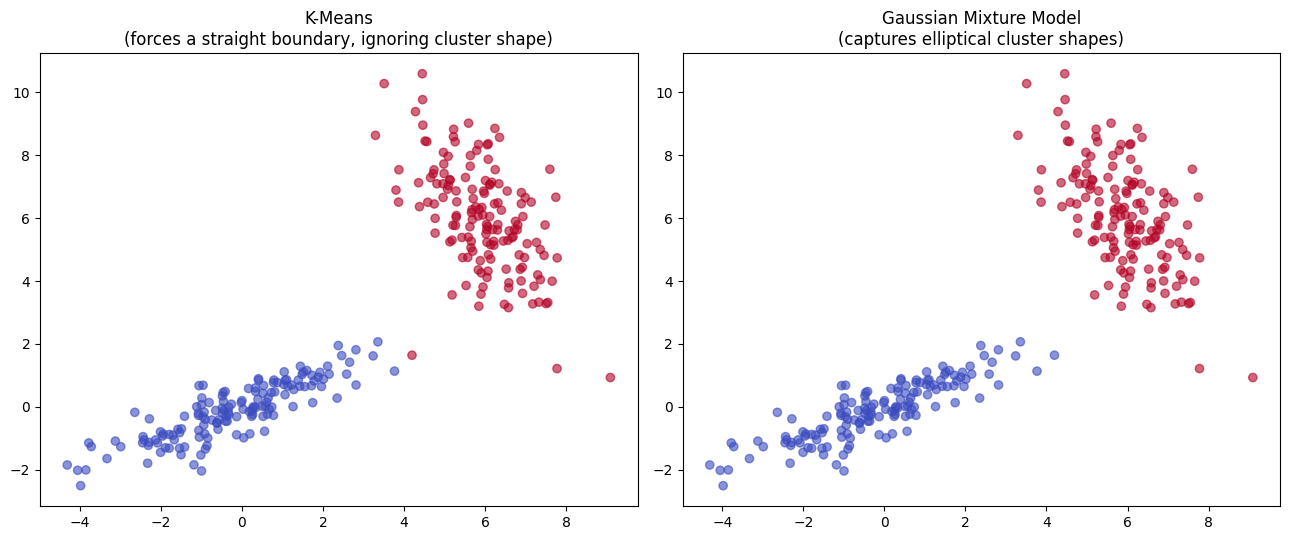

Points closest to the decision boundary (soft/ambiguous assignments):
  Point 264: P(cluster 0)=0.018, P(cluster 1)=0.982
  Point 281: P(cluster 0)=0.015, P(cluster 1)=0.985
  Point 265: P(cluster 0)=0.003, P(cluster 1)=0.997
  Point 165: P(cluster 0)=0.003, P(cluster 1)=0.997
  Point 263: P(cluster 0)=0.002, P(cluster 1)=0.998


In [11]:
# Fit a GMM on elliptical (non-spherical) clusters where K-Means struggles
np.random.seed(10)
cluster_A = np.random.multivariate_normal([0, 0], [[3, 1.5], [1.5, 1]], 150)
cluster_B = np.random.multivariate_normal([6, 6], [[1, -0.8], [-0.8, 3]], 150)
X_elliptical = np.vstack([cluster_A, cluster_B])

kmeans_ell = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X_elliptical)
gmm_ell = GaussianMixture(n_components=2, random_state=42).fit(X_elliptical)
gmm_labels = gmm_ell.predict(X_elliptical)
gmm_probs = gmm_ell.predict_proba(X_elliptical)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].scatter(X_elliptical[:, 0], X_elliptical[:, 1], c=kmeans_ell.labels_, cmap='coolwarm', alpha=0.6)
axes[0].set_title("K-Means\n(forces a straight boundary, ignoring cluster shape)")

axes[1].scatter(X_elliptical[:, 0], X_elliptical[:, 1], c=gmm_labels, cmap='coolwarm', alpha=0.6)
axes[1].set_title("Gaussian Mixture Model\n(captures elliptical cluster shapes)")

plt.tight_layout()
plt.show()

# Show soft assignment probabilities for a few ambiguous (boundary) points
boundary_idx = np.argsort(np.abs(gmm_probs[:, 0] - 0.5))[:5]
print("Points closest to the decision boundary (soft/ambiguous assignments):")
for idx in boundary_idx:
    print(f"  Point {idx}: P(cluster 0)={gmm_probs[idx,0]:.3f}, P(cluster 1)={gmm_probs[idx,1]:.3f}")


## 6. K-Means vs DBSCAN: When to Use Each

| | K-Means | DBSCAN |
|---|---|---|
| Need to specify K? | Yes | No (discovers clusters automatically) |
| Cluster shape assumption | Roughly spherical, similar size | Arbitrary shape, based on density |
| Handles outliers? | No — every point forced into a cluster | Yes — explicitly labels noise |
| Handles varying density? | N/A (not density-based) | Struggles if densities vary a lot |
| Scalability | Very scalable, fast | Can be slower on very large datasets (though optimized implementations exist) |
| Interpretability | Simple: centroid = cluster "prototype" | Less immediately interpretable (no single "center") |
| Best for | Customer segmentation, compact well-separated groups | Anomaly/outlier detection, irregularly shaped clusters (geospatial data, image segmentation) |

**Rule of thumb**: if you expect roughly round, similarly-sized groups and know (or can estimate) $K$ → **K-Means**. If you suspect **irregular shapes, unknown cluster count, or meaningful outliers/noise** → **DBSCAN**.


## 7. Mini Project — Customer Segmentation

**Goal:** Apply K-Means end-to-end on a realistic customer dataset: scale the data, select $K$ using elbow + silhouette analysis, then analyze and interpret the resulting cluster characteristics — the required daily output.


In [12]:
# Build a realistic synthetic customer dataset (Annual Income vs Spending Score, a classic segmentation setup)
np.random.seed(11)

# Simulate a few natural customer segments
segment_budget = np.random.normal([25, 25], [8, 10], (60, 2))       # low income, low spending
segment_standard = np.random.normal([55, 50], [10, 12], (80, 2))     # mid income, mid spending
segment_premium = np.random.normal([85, 80], [8, 8], (50, 2))        # high income, high spending
segment_frugal_rich = np.random.normal([80, 20], [8, 8], (40, 2))    # high income, LOW spending (frugal)
segment_impulsive = np.random.normal([25, 75], [8, 8], (40, 2))      # low income, HIGH spending (impulsive)

customer_data = np.vstack([segment_budget, segment_standard, segment_premium,
                            segment_frugal_rich, segment_impulsive])
customer_df = pd.DataFrame(customer_data, columns=['AnnualIncome_k', 'SpendingScore'])
customer_df['AnnualIncome_k'] = customer_df['AnnualIncome_k'].clip(lower=5)
customer_df['SpendingScore'] = customer_df['SpendingScore'].clip(1, 100)

print("Customer dataset shape:", customer_df.shape)
customer_df.describe()


Customer dataset shape: (270, 2)


,AnnualIncome_k,SpendingScore
count,270.0000,270.0000
mean,52.8767,48.9337
std,25.2724,25.7670
min,6.3575,1.0000
25%,29.7527,25.3214
50%,51.9252,49.4450
75%,77.0890,71.9842
max,98.8175,96.6910


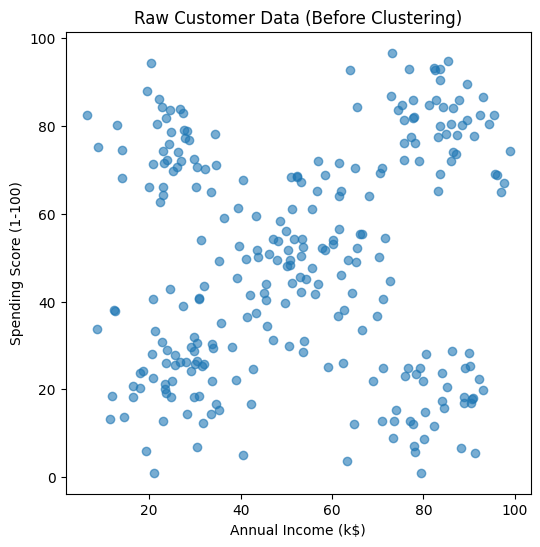

In [13]:
# Step 1: Scale the data (critical for K-Means -- distance-based algorithm, recall Day 4)
scaler = StandardScaler()
customer_scaled = scaler.fit_transform(customer_df)

plt.figure(figsize=(6, 6))
plt.scatter(customer_df['AnnualIncome_k'], customer_df['SpendingScore'], alpha=0.6)
plt.xlabel("Annual Income (k$)"); plt.ylabel("Spending Score (1-100)")
plt.title("Raw Customer Data (Before Clustering)")
plt.show()


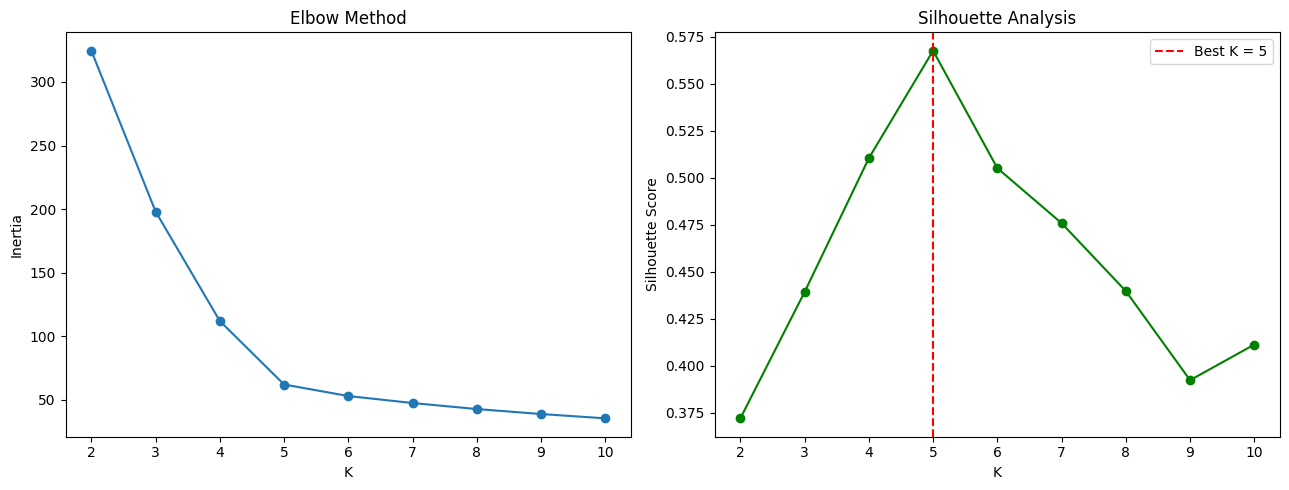

Chosen K = 5 (by silhouette score, confirmed visually via elbow)


In [14]:
# Step 2: Select K using elbow method + silhouette score
K_range_customer = range(2, 11)
inertias_c, silhouettes_c = [], []

for k in K_range_customer:
    km_c = KMeans(n_clusters=k, n_init=10, random_state=42).fit(customer_scaled)
    inertias_c.append(km_c.inertia_)
    silhouettes_c.append(silhouette_score(customer_scaled, km_c.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(K_range_customer), inertias_c, marker='o')
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia"); axes[0].set_title("Elbow Method")

axes[1].plot(list(K_range_customer), silhouettes_c, marker='o', color='green')
best_k_customer = list(K_range_customer)[np.argmax(silhouettes_c)]
axes[1].axvline(best_k_customer, color='red', linestyle='--', label=f'Best K = {best_k_customer}')
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette Score"); axes[1].set_title("Silhouette Analysis")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Chosen K = {best_k_customer} (by silhouette score, confirmed visually via elbow)")


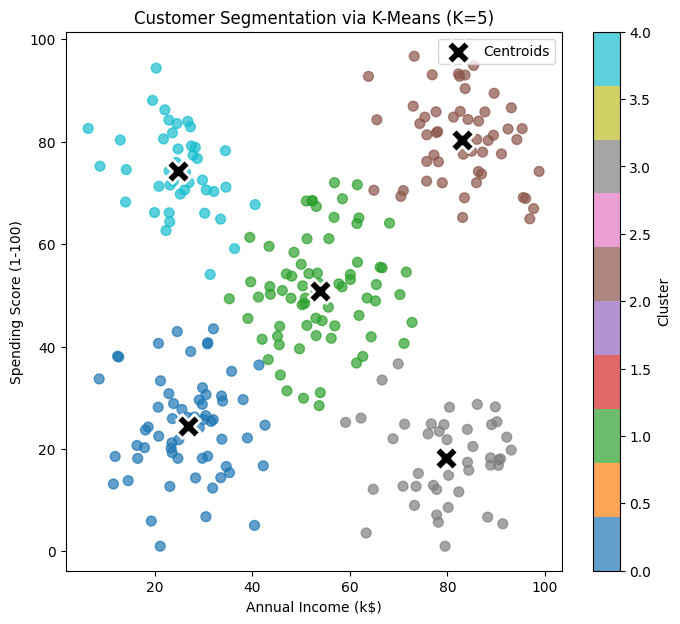

In [15]:
# Step 3: Apply K-Means with the chosen K
final_kmeans = KMeans(n_clusters=best_k_customer, n_init=10, random_state=42)
customer_df['Cluster'] = final_kmeans.fit_predict(customer_scaled)

# Visualize the final segmentation (Cluster Visualization -- required daily output)
plt.figure(figsize=(8, 7))
scatter = plt.scatter(customer_df['AnnualIncome_k'], customer_df['SpendingScore'],
                       c=customer_df['Cluster'], cmap='tab10', alpha=0.7, s=50)

# Un-scale centroids back to original units for plotting
centroids_original = scaler.inverse_transform(final_kmeans.cluster_centers_)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1], c='black', marker='X', s=300,
            edgecolor='white', linewidth=2, label='Centroids')

plt.xlabel("Annual Income (k$)"); plt.ylabel("Spending Score (1-100)")
plt.title(f"Customer Segmentation via K-Means (K={best_k_customer})")
plt.legend()
plt.colorbar(scatter, label='Cluster')
plt.show()


In [16]:
# Step 4: Analyze and INTERPRET cluster characteristics (required daily output)
cluster_summary = customer_df.groupby('Cluster').agg(
    Count=('AnnualIncome_k', 'size'),
    Avg_Income=('AnnualIncome_k', 'mean'),
    Avg_Spending=('SpendingScore', 'mean')
).round(2)

print(cluster_summary)

print("\n--- Cluster Interpretation ---")
for cluster_id, row in cluster_summary.iterrows():
    income, spending = row['Avg_Income'], row['Avg_Spending']
    if income < 40 and spending < 40:
        label = "Budget Shoppers (low income, low spending)"
    elif income < 40 and spending >= 60:
        label = "Impulsive Spenders (low income, HIGH spending -- interesting/risky segment!)"
    elif income >= 60 and spending < 40:
        label = "Frugal High-Earners (high income, LOW spending -- untapped upsell potential)"
    elif income >= 60 and spending >= 60:
        label = "Premium Customers (high income, high spending -- most valuable segment)"
    else:
        label = "Standard/Average Customers (moderate income & spending)"
    print(f"Cluster {cluster_id} ({int(row['Count'])} customers): {label}")

print("\n--> This kind of interpretation is exactly what turns raw clustering output into")
print("    actionable business insight -- e.g., target 'Frugal High-Earners' with premium")
print("    product marketing, since they have the income but aren't currently spending much.")


         Count  Avg_Income  Avg_Spending
Cluster                                 
0           62       26.72         24.53
1           71       53.98         50.83
2           52       82.95         80.37
3           43       79.76         18.13
4           42       24.87         74.35

--- Cluster Interpretation ---
Cluster 0 (62 customers): Budget Shoppers (low income, low spending)
Cluster 1 (71 customers): Standard/Average Customers (moderate income & spending)
Cluster 2 (52 customers): Premium Customers (high income, high spending -- most valuable segment)
Cluster 3 (43 customers): Frugal High-Earners (high income, LOW spending -- untapped upsell potential)
Cluster 4 (42 customers): Impulsive Spenders (low income, HIGH spending -- interesting/risky segment!)

--> This kind of interpretation is exactly what turns raw clustering output into
    actionable business insight -- e.g., target 'Frugal High-Earners' with premium
    product marketing, since they have the income but aren't 

## ML Connection Recap

| Concept | Connects to |
|---|---|
| K-Means distance-based assignment | Day 1's Euclidean/L2 norm, Day 6's KNN |
| Feature scaling before K-Means | Day 4's standardization (critical — same reasoning as KNN) |
| Elbow method / inertia | Similar "diminishing returns" shape to Day 9's n_estimators tuning curve |
| GMM's Expectation-Maximization | Day 3's probability/Gaussian distribution foundations |
| DBSCAN density-based outlier detection | Preview of Day 16's Anomaly Detection |


## 8. Interview Questions — Practice Aloud (Close Your Notes!)

1. **Explain how K-Means works, step by step.**
   *Hint: initialize centroids → assign points to nearest centroid → update centroids to cluster means → repeat until convergence.*

2. **Why does K-Means require feature scaling?**
   *Hint: purely distance-based (Euclidean); unscaled features with larger ranges would dominate cluster assignment.*

3. **How would you choose the right number of clusters K?**
   *Hint: elbow method (visual, inertia vs K) and silhouette score (quantitative, maximize average silhouette).*

4. **Compare K-Means and DBSCAN — when would you choose each?**
   *Hint: K-Means needs K upfront, assumes spherical clusters; DBSCAN discovers cluster count automatically, handles arbitrary shapes and outliers, but struggles with varying density.*

5. **What's the difference between K-Means's hard assignments and GMM's soft assignments?**
   *Hint: K-Means assigns each point to exactly one cluster; GMM gives a probability distribution over all clusters per point.*

6. **What is a dendrogram, and what's an advantage of hierarchical clustering over K-Means?**
   *Hint: a tree showing nested merges; doesn't require choosing K upfront — can inspect and cut at any level.*

7. **(Bonus) What are the two key parameters of DBSCAN, and what happens if `eps` is set too small or too large?**
   *Hint: eps (neighborhood radius) and min_samples; too small eps → most points become noise; too large eps → clusters merge together incorrectly.*


## 9. Active Recall & Daily Output

**Self-check (mark ✔ only if you can do this without notes):**
- [ ] Explain K-Means's algorithm and what "inertia" measures.
- [ ] Explain the elbow method and silhouette score, and how to use each to choose K.
- [ ] Explain hierarchical clustering, dendrograms, and at least two linkage criteria.
- [ ] Explain DBSCAN's core/border/noise point types and its two key parameters.
- [ ] Explain Gaussian Mixture Models and how they differ from K-Means (soft vs hard assignment).
- [ ] Compare K-Means and DBSCAN and identify which fits a given scenario.
- [ ] Apply K-Means end-to-end: scale data, choose K, fit, visualize, and interpret clusters.

### 📌 Daily Output (per the planner)
A **cluster visualization + interpretation** (Section 7, Mini Project: Customer Segmentation) — customer data scaled, K chosen via elbow + silhouette analysis, K-Means applied, clusters visualized with centroids, and each resulting segment interpreted in plain business terms (e.g., "Premium Customers," "Frugal High-Earners").

Close this notebook and re-derive the cluster interpretation labels from the raw cluster summary table alone — that's the real test of Day 11 mastery.
